In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Set visualization style
sns.set_theme(style="whitegrid")
%matplotlib inline

# Load datasets
calories = pd.read_csv('../data/raw/calories.csv')
exercise = pd.read_csv('../data/raw/exercise.csv')

# Merge them on User_ID
df = pd.merge(exercise, calories, on='User_ID')

# Drop User_ID as it's not a feature
df.drop(columns=['User_ID'], inplace=True)

print(f"Dataset Shape: {df.shape}")
df.head()


Dataset Shape: (15000, 8)


,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [3]:
print("--- Data Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Descriptive Statistics ---")
df.describe()


--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      15000 non-null  str    
 1   Age         15000 non-null  int64  
 2   Height      15000 non-null  float64
 3   Weight      15000 non-null  float64
 4   Duration    15000 non-null  float64
 5   Heart_Rate  15000 non-null  float64
 6   Body_Temp   15000 non-null  float64
 7   Calories    15000 non-null  float64
dtypes: float64(6), int64(1), str(1)
memory usage: 937.6 KB

--- Missing Values ---
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

--- Descriptive Statistics ---


,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


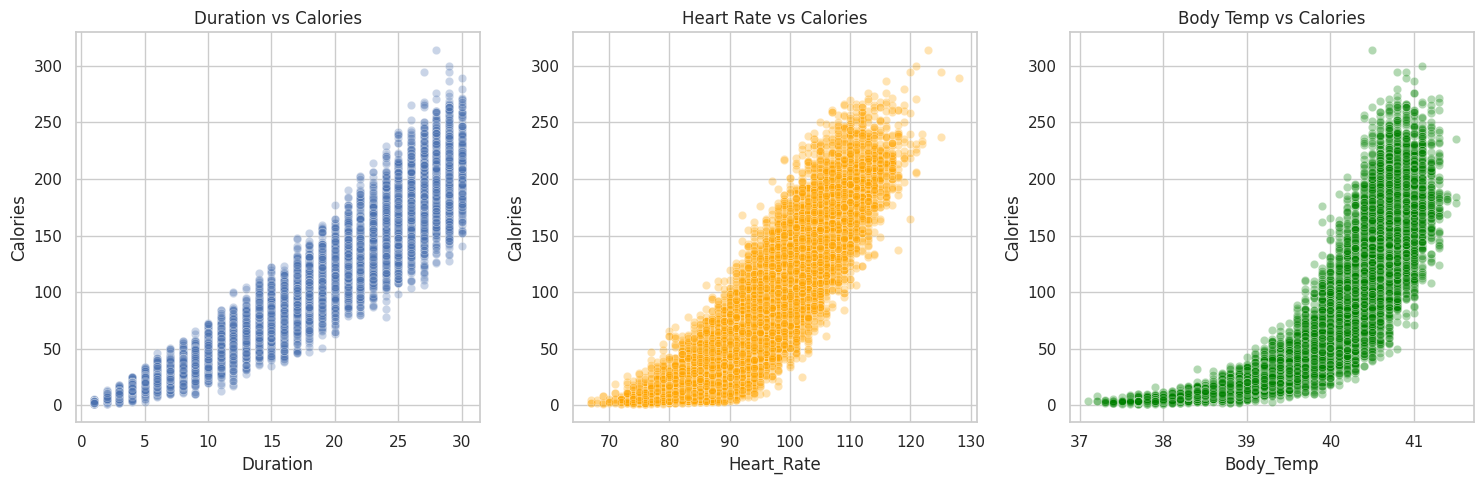

In [4]:
plt.figure(figsize=(15, 5))

# Plot 1: Duration vs Calories
plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='Duration', y='Calories', alpha=0.3)
plt.title('Duration vs Calories')

# Plot 2: Heart Rate vs Calories
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='Heart_Rate', y='Calories', color='orange', alpha=0.3)
plt.title('Heart Rate vs Calories')

# Plot 3: Body Temp vs Calories
plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='Body_Temp', y='Calories', color='green', alpha=0.3)
plt.title('Body Temp vs Calories')

plt.tight_layout()
plt.show()


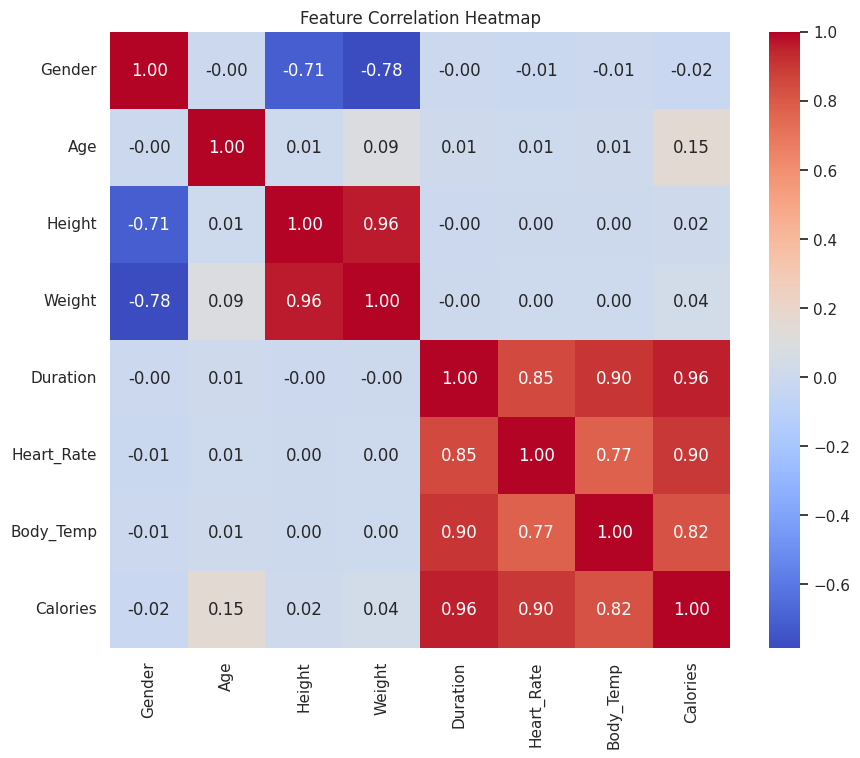

In [5]:
# Convert Gender to numeric for correlation (0 for male, 1 for female)
df_numeric = df.copy()
df_numeric['Gender'] = df_numeric['Gender'].map({'male': 0, 'female': 1})

plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()


In [6]:
# Encode gender if present
df_model = df.copy()
if 'Gender' in df_model.columns:
    df_model['Gender'] = df_model['Gender'].map({'male': 0, 'female': 1})

# Features and target
X = df_model.drop(columns=['Calories'])
y = df_model['Calories']

# Train / test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (12000, 7) Test shape: (3000, 7)


In [7]:
from sklearn.preprocessing import StandardScaler

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])


In [8]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = lr.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Calculate RMSE manually
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")


MAE: 8.44
RMSE: 11.49
R²: 0.967


In [11]:
coef_df = (
    pd.DataFrame({
        'feature': X_train_scaled.columns,
        'coefficient': lr.coef_
    })
    .assign(abs_coef=lambda d: d['coefficient'].abs())
    .sort_values('abs_coef', ascending=False)
)
coef_df


,feature,coefficient,abs_coef
4,Duration,55.026936,55.026936
5,Heart_Rate,18.993007,18.993007
6,Body_Temp,-13.179476,13.179476
1,Age,8.499936,8.499936
3,Weight,4.296298,4.296298
2,Height,-2.413582,2.413582
0,Gender,0.687084,0.687084


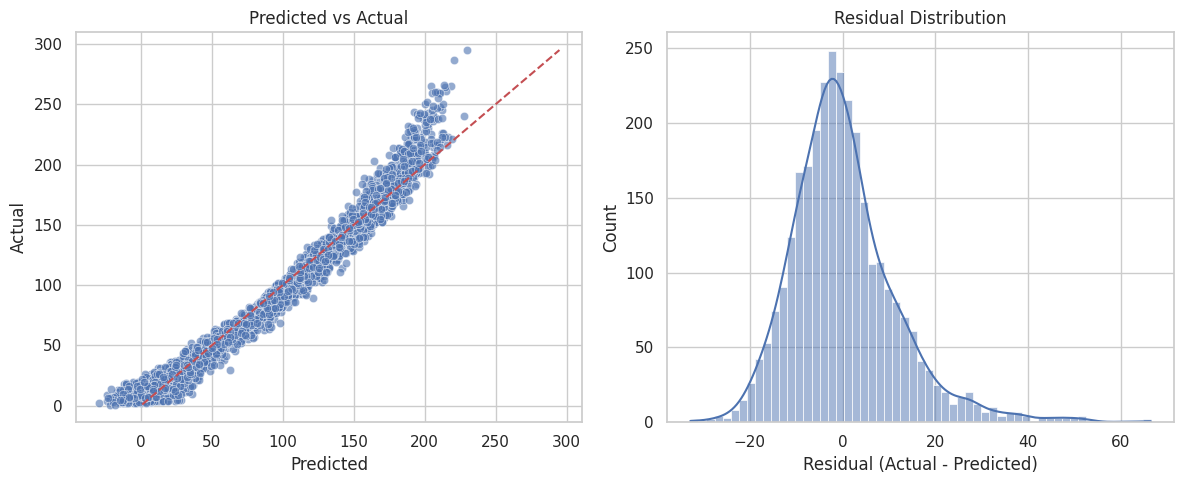

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test - y_pred

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(x=y_pred, y=y_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Predicted vs Actual")

plt.subplot(1,2,2)
sns.histplot(residuals, kde=True)
plt.xlabel("Residual (Actual - Predicted)")
plt.title("Residual Distribution")

plt.tight_layout()
plt.show()
